In [3]:
import numpy as np
np.int = int
import matplotlib.pyplot as plt
from reg_utils import sigmoid, relu, plot_decision_boundary, initialize_parameters, load_2D_dataset, predict_dec
from reg_utils import compute_cost, predict, forward_propagation, backward_propagation, update_parameters

import sklearn
import sklearn.datasets
import scipy.io


plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

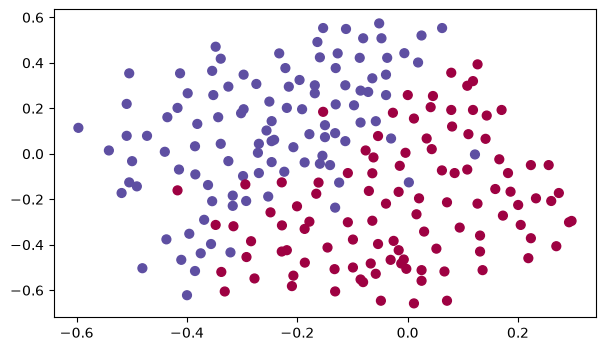

In [4]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

In [5]:
def model(X,Y, learning_rate = 0.3, num_iterations = 30000, print_cost = True,lambd=0,keep_prob = 1):
    
    costs = []
    layers_dims = [X.shape[0], 20,3,1]
    parameters = initialize_parameters(layers_dims)
    
    for i in range(num_iterations):
        if keep_prob == 1:
            A3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            A3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)
        if lambd == 0:
            cost = compute_cost(A3,Y)
        elif lambd > 0:
            cost = compute_cost_with_regularization(A3, Y, parameters, lambd)
        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X,Y,cache)
        elif lambd > 0:
            grads = backward_propagation_with_regularization(X,Y,cache, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost == True:
                print(f"cost after iterations {i}: {cost}")
    
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()

    return parameters
        

cost after iterations 0: 0.6557412523481002
cost after iterations 100: 0.23825421577858988
cost after iterations 200: 0.23216777356768373
cost after iterations 300: 0.2309091719059324
cost after iterations 400: 0.23000481548884624
cost after iterations 500: 0.2292132894750506
cost after iterations 600: 0.22838535576239016
cost after iterations 700: 0.22735384358621927
cost after iterations 800: 0.22613772513893118
cost after iterations 900: 0.22453439502222647
cost after iterations 1000: 0.2222669386845115
cost after iterations 1100: 0.22106411992048552
cost after iterations 1200: 0.21998462156734244
cost after iterations 1300: 0.2181686017027537
cost after iterations 1400: 0.2164224848689754
cost after iterations 1500: 0.2136812080515376
cost after iterations 1600: 0.21184908110552714
cost after iterations 1700: 0.20941542160501705
cost after iterations 1800: 0.2068563418950768
cost after iterations 1900: 0.20398460971080862
cost after iterations 2000: 0.20288702607598852
cost after i

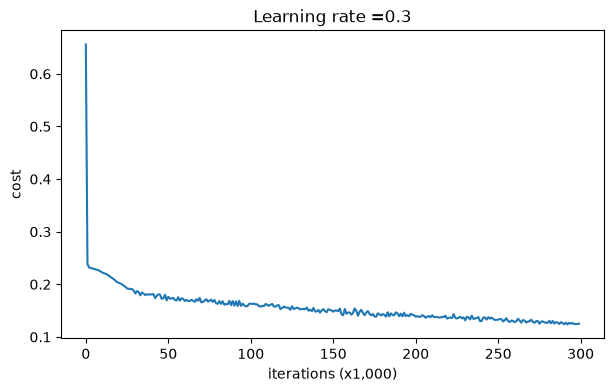

On the training set:
Accuracy: 0.9478672985781991
On the test set:
Accuracy: 0.915


In [6]:

parameters = model(train_X, train_Y)
print ("On the training set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)

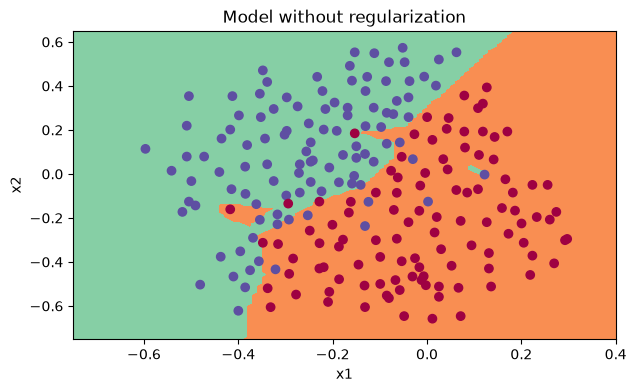

In [7]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)

## L2 Regularization

In [8]:
def compute_cost_with_regularization(A3, Y, parameters, lambd):
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]
    
    cross_entropy_cost = compute_cost(A3, Y)
    

    total_squared_sum = np.sum(np.square(W1)) + np.sum(np.square(W2)) + np.sum(np.square(W3))

    L2_regularization_cost = total_squared_sum * (1 / m) * (lambd / 2)

    
    cost = cross_entropy_cost + L2_regularization_cost
    
    return cost


In [9]:
def backward_propagation_with_regularization(X, Y, cache, lambd):
   

    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache
    
    # Layer 3 Gradients
    dZ3 = A3 - Y
    dW3 = 1./m * np.dot(dZ3, A2.T) + (lambd / m) * W3
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims = True)
    
    # Layer 2 Gradients
    dA2 = np.dot(W3.T, dZ3)
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1./m * np.dot(dZ2, A1.T) + (lambd / m) * W2
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims = True)
    
    # Layer 1 Gradients
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1./m * np.dot(dZ1, X.T) + (lambd / m) * W1
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims = True)
    
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3, "dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1,
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}
    
    return gradients


cost after iterations 0: 0.6974484493131264
cost after iterations 100: 0.30065029640773444
cost after iterations 200: 0.28968727980319037
cost after iterations 300: 0.285359162431322
cost after iterations 400: 0.28217882274185413
cost after iterations 500: 0.27968572163455435
cost after iterations 600: 0.2777032796441016
cost after iterations 700: 0.2761227193659193
cost after iterations 800: 0.2748675752717567
cost after iterations 900: 0.27386482772414866
cost after iterations 1000: 0.27304563479326766
cost after iterations 1100: 0.2723683720433098
cost after iterations 1200: 0.27180856244725166
cost after iterations 1300: 0.27135326025511025
cost after iterations 1400: 0.2709746717820962
cost after iterations 1500: 0.2706677883394516
cost after iterations 1600: 0.27042941963232076
cost after iterations 1700: 0.2701736742090459
cost after iterations 1800: 0.2699987938002402
cost after iterations 1900: 0.2698506028243918
cost after iterations 2000: 0.2698576079833293
cost after iterat

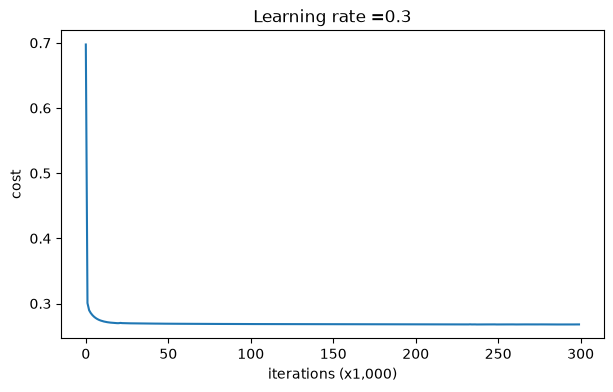

On the train set:
Accuracy: 0.9383886255924171
On the test set:
Accuracy: 0.93


In [10]:
parameters = model(train_X, train_Y, lambd = 0.7)
print ("On the train set:")
predictions_train = predict(train_X, train_Y, parameters)
print ("On the test set:")
predictions_test = predict(test_X, test_Y, parameters)


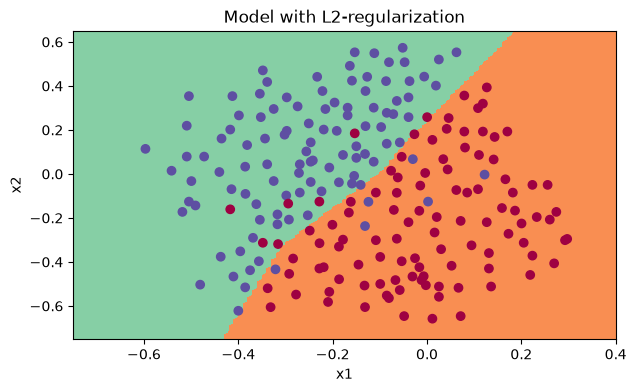

In [11]:

plt.title("Model with L2-regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)